# The $df$ for the undenoised galaxy, standard N2V denoising, constrained N2V denoising and LoRA-N2V denoising.

We used the data from the PAUS band NB645.

In [15]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm


In [2]:
def background_annulus(data, mask, aperture_x, aperture_y, r_in=25, r_out=45):#r_in=30
    """Measure background in an annulus."""
    
    masked_data = np.ma.array(data=data, mask=mask != 0)
    masked_data = masked_data.filled(fill_value=0)

    center = (aperture_x, aperture_y)
    annulus_apertures = CircularAnnulus(center, r_in=r_in, r_out=r_out)
    masks = annulus_apertures.to_mask(method='center')

    cutout_data = masks.cutout(masked_data)

    clip_annulus_array = sigma_clip(cutout_data[cutout_data != 0], sigma=3, maxiters=2)

    S = pd.Series()
    S['annulus_mean'] = np.ma.mean(clip_annulus_array)
    S['annulus_median'] = np.ma.median(clip_annulus_array)
    S['annulus_std'] = np.ma.std(clip_annulus_array)
    S['annulus_samples'] = np.ma.count(clip_annulus_array)

    return S

def flux_elliptical(image, mask, aperture_x, aperture_y, aperture_theta, aperture_a, aperture_b):
    """Measure the flux withing an elliptical aperture."""
    
    PIXEL_SCALE = 0.263
    theta = -aperture_theta * np.pi / 180.
    a = aperture_a / PIXEL_SCALE
    b = aperture_b / PIXEL_SCALE

    center = (aperture_x, aperture_y)
    source_aperture = EllipticalAperture(center, a, b, theta)

    xmask = mask != 0
    raw_flux = aperture_photometry(image, source_aperture, mask=xmask)
   
    S = pd.Series()
    S['raw_flux'] = float(raw_flux['aperture_sum'][0])
    S['area'] = source_aperture.area
    
    return S

def cal_calerror(sig_src,sig_zp,zp,f_src):
    sig_cal = np.sqrt(sig_src**2 * sig_zp**2 + sig_src**2 * zp**2 + sig_zp**2 * f_src**2)
    return sig_cal

def cal_fcal(f_src,zp):
    f_cal = f_src * zp
    return f_cal

def creat_stamps(image, sources):
    y = math.floor(sources['aperture_x'].values[0])
    x = math.floor(sources['aperture_y'].values[0])
    #y = math.floor(sources['aperture_x'])
    #x = math.floor(sources['aperture_y'])
    x_start = max((x - cutout_size), 0)
    x_end = min((x + cutout_size), image.shape[0])
    y_start = max((y - cutout_size), 0)
    y_end = min((y + cutout_size), image.shape[1])

    stamps = image[x_start:x_end, y_start:y_end]
    return stamps

def photometry_oneimage(image, mask, aperture_x, aperture_y, aperture_theta, aperture_a, aperture_b):
    
    S1 = background_annulus(image, mask, aperture_x, aperture_y)
    S2 = flux_elliptical(image, mask, aperture_x, aperture_y, aperture_theta, aperture_a, aperture_b)

    flux_obs = S2['raw_flux'] - S2['area'] * S1['annulus_mean']
    return flux_obs

def generate_mask(size_data, image):

    num_sample = int(size_data[0] * size_data[1] * (1 - ratio))
    mask = np.ones(size_data)
    output = image

    for ich in range(size_data[2]):
        idy_msk = np.random.randint(0, size_data[0], num_sample)
        idx_msk = np.random.randint(0, size_data[1], num_sample)

        idy_neigh = np.random.randint(-size_window[0] // 2 + size_window[0] % 2, size_window[0] // 2 + size_window[0] % 2, num_sample)
        idx_neigh = np.random.randint(-size_window[1] // 2 + size_window[1] % 2, size_window[1] // 2 + size_window[1] % 2, num_sample)

        idy_msk_neigh = idy_msk + idy_neigh
        idx_msk_neigh = idx_msk + idx_neigh

        idy_msk_neigh = idy_msk_neigh + (idy_msk_neigh < 0) * size_data[0] - (idy_msk_neigh >= size_data[0]) * size_data[0]
        idx_msk_neigh = idx_msk_neigh + (idx_msk_neigh < 0) * size_data[1] - (idx_msk_neigh >= size_data[1]) * size_data[1]

        id_msk = (idy_msk, idx_msk, ich)
        id_msk_neigh = (idy_msk_neigh, idx_msk_neigh, ich)

        output[id_msk] = image[id_msk_neigh]
        mask[id_msk] = 0.0

    return output, mask

In [16]:
path = '../data saved/'

In [17]:
trainingset = pd.read_csv(path + 'lora-n2v_trainingset.csv')

In [19]:
#constrained N2V
combined_NB705 = pd.read_csv(path + 'constrained_n2v_denoised.csv')

In [18]:
#standard N2V
denoisedgalaxybefore = pd.read_csv(path + 'standard_n2v_denoised.csv')

In [20]:
#lora-n2v
denoisedgalaxyafter2223 = pd.read_csv(path + 'lora-n2v_denoised_singleband_22-23.csv')
denoisedgalaxyafter1721 = pd.read_csv(path + 'lora-n2v_denoised_singleband_17-21.csv')
denoisedgalaxyafter2122 = pd.read_csv(path + 'lora-n2v_denoised_singleband_21-22.csv')

In [21]:
denoisedgalaxyafter = pd.concat([denoisedgalaxyafter1721, denoisedgalaxyafter2122,
                                 denoisedgalaxyafter2223], axis=0, ignore_index=True)

In [22]:
#remove the training galaxy
merged = denoisedgalaxyafter.merge(
    trainingset[['ref_id', 'path']], 
    on=['ref_id', 'path'], 
    how='left', 
    indicator=True
)

denoisedgalaxyafter_clean = merged[merged['_merge'] == 'left_only'].drop('_merge', axis=1)

In [23]:
#df of the no denoising
denoisedgalaxyafter['flux_ca_error'] = cal_calerror(denoisedgalaxyafter['flux_error'],denoisedgalaxyafter['zp_error'],denoisedgalaxyafter['zp'],denoisedgalaxyafter['flux_obs'])
denoisedgalaxyafter['flux_ca'] = cal_fcal(denoisedgalaxyafter['flux_obs'],denoisedgalaxyafter['zp'])

comb = pd.merge(denoisedgalaxyafter,denoisedgalaxyafter,on = ['ref_id','filter'])
comb['df'] = (comb['flux_ca_x'] - comb['flux_ca_y'])/np.sqrt(comb['flux_ca_error_x']**2 + comb['flux_ca_error_y']**2)
comb = comb[comb.image_id_x != comb.image_id_y]

In [24]:
#df of the constrained n2v
combb705 = pd.merge(combined_NB705,combined_NB705,on = ['ref_id','filter'])
combb705['df1'] = (combb705['flux_ca_x'] - combb705['flux_ca_y'])/np.sqrt(combb705['flux_ca_error_x']**2 + combb705['flux_ca_error_y']**2)
combb705['df2'] = (combb705['flux_ca_obs_x'] - combb705['flux_ca_obs_y'])/np.sqrt(combb705['flux_ca_error_x']**2 + combb705['flux_ca_error_y']**2)
combb705 = combb705[combb705.image_id_x != combb705.image_id_y]

In [25]:
#df of the lora-n2v
denoisedgalaxyafter_clean['flux_ca_error'] = cal_calerror(denoisedgalaxyafter_clean['flux_error'],denoisedgalaxyafter_clean['zp_error'],denoisedgalaxyafter_clean['zp'],denoisedgalaxyafter_clean['flux_obs'])
denoisedgalaxyafter_clean['flux_ca'] = cal_fcal(denoisedgalaxyafter_clean['flux_obs'],denoisedgalaxyafter_clean['zp'])

denoisedgalaxyafter_clean['flux_ca_error_obs'] = cal_calerror(denoisedgalaxyafter_clean['flux_error'],denoisedgalaxyafter_clean['zp_error'],denoisedgalaxyafter_clean['zp'],denoisedgalaxyafter_clean['flux_obs_denoised'])
denoisedgalaxyafter_clean['flux_ca_obs'] = cal_fcal(denoisedgalaxyafter_clean['flux_obs_denoised'],denoisedgalaxyafter_clean['zp'])

denoisedgalaxyafter_clean['snr'] = denoisedgalaxyafter_clean['flux_ca_obs'] / (denoisedgalaxyafter_clean['area'] * denoisedgalaxyafter_clean['annulus_std'])

combb = pd.merge(denoisedgalaxyafter_clean,denoisedgalaxyafter_clean,on = ['ref_id','filter'])
combb['df1'] = (combb['flux_ca_x'] - combb['flux_ca_y'])/np.sqrt(combb['flux_ca_error_x']**2 + combb['flux_ca_error_y']**2)
combb['df2'] = (combb['flux_ca_obs_x'] - combb['flux_ca_obs_y'])/np.sqrt(combb['flux_ca_error_x']**2 + combb['flux_ca_error_y']**2)
combb = combb[combb.image_id_x != combb.image_id_y]

In [26]:
#df of the standard n2v
denoisedgalaxybefore['flux_ca_error'] = cal_calerror(denoisedgalaxybefore['flux_error'],denoisedgalaxybefore['zp_error'],denoisedgalaxybefore['zp'],denoisedgalaxybefore['flux_obs'])
denoisedgalaxybefore['flux_ca'] = cal_fcal(denoisedgalaxybefore['flux_obs'],denoisedgalaxybefore['zp'])

denoisedgalaxybefore['flux_ca_error_obs'] = cal_calerror(denoisedgalaxybefore['flux_error'],denoisedgalaxybefore['zp_error'],denoisedgalaxybefore['zp'],denoisedgalaxybefore['flux_obs_denoised'])
denoisedgalaxybefore['flux_ca_obs'] = cal_fcal(denoisedgalaxybefore['flux_obs_denoised'],denoisedgalaxybefore['zp'])

denoisedgalaxybefore['snr'] = denoisedgalaxybefore['flux_ca_obs'] / (denoisedgalaxybefore['area'] * denoisedgalaxybefore['annulus_std'])

combbbefore = pd.merge(denoisedgalaxybefore,denoisedgalaxybefore,on = ['ref_id','filter'])
combbbefore['df1'] = (combbbefore['flux_ca_x'] - combbbefore['flux_ca_y'])/np.sqrt(combbbefore['flux_ca_error_x']**2 + combbbefore['flux_ca_error_y']**2)
combbbefore['df2'] = (combbbefore['flux_ca_obs_x'] - combbbefore['flux_ca_obs_y'])/np.sqrt(combbbefore['flux_ca_error_x']**2 + combbbefore['flux_ca_error_y']**2)
combbbefore = combbbefore[combbbefore.image_id_x != combbbefore.image_id_y]

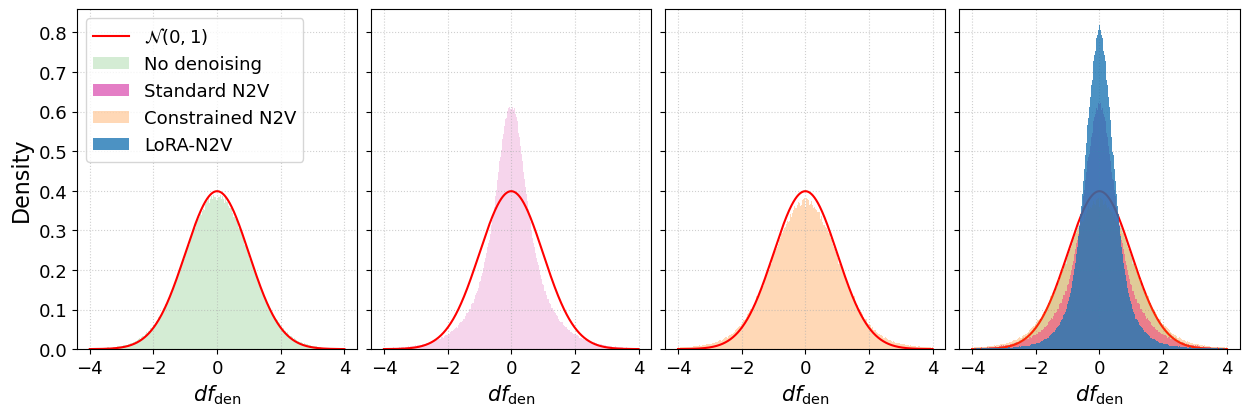

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=True)

x_range = np.linspace(-4, 4, 500)
x_curve = np.linspace(-4, 4, 33266)
y_curve = norm.pdf(x_curve)

axes[0].hist(comb.df, bins=x_range, density=True, alpha=0.2, 
             label='Without denoising', color='tab:green')
axes[0].plot(x_curve, y_curve, color='red', label='Normal distribution')

axes[1].hist(combbbefore.df2, bins=x_range, density=True, alpha=0.3, 
             label='N2V denoising', color='tab:pink')
axes[1].plot(x_curve, y_curve, color='red', label='Normal distribution')

axes[2].hist(combb705.df2, bins=x_range, density=True, alpha=0.3, 
             label='Flux-preserving modified N2V denoising', color='tab:orange')
axes[2].plot(x_curve, y_curve, color='red', label='Normal distribution')

axes[3].plot(x_curve, y_curve, color='red', label=r'$ \mathcal{N}(0,1) $')
axes[3].hist(comb.df, bins=x_range, density=True, alpha=0.2, 
             label='No denoising', color='tab:green', zorder=1)
axes[3].hist(combbbefore.df2, bins=x_range, density=True, alpha=0.95, 
             label='Standard N2V', color='tab:pink')
axes[3].hist(combb705.df2, bins=x_range, density=True, alpha=0.3, 
             label='Constrained N2V', color='tab:orange', zorder=2)
axes[3].hist(combb.df2, bins=x_range, density=True, alpha=0.8, 
             label='LoRA-N2V', color='tab:blue', zorder=3)

handles, labels = axes[3].get_legend_handles_labels()

axes[0].legend(handles, labels, fontsize=13, loc='upper left', frameon=True)

for ax in axes:
    ax.set_xlabel(r'$df_{\mathrm{den}}$', fontsize=15)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.tick_params(axis='both', labelsize=13)

axes[0].set_ylabel('Density', fontsize=16)

plt.subplots_adjust(wspace=0.05, bottom=0.2)
plt.show()